# 📧 SMS & Email Spam Detection using Logistic Regression & NLP
### 🚀 Supervised Classification Master Pipeline: From Raw Text to Production Deployment

---

## 📌 Project Overview & Objectives
- **Business Context**: Unsolicited bulk messages (Spam) clutter corporate inboxes, drain employee productivity, and present severe cybersecurity & phishing risks. An enterprise filtering system must achieve high spam detection while strictly suppressing **False Positives (Type I Error)** so legitimate business and personal communications are never mistakenly lost.
- **Machine Learning Track**: Supervised Binary Classification ($0 = \text{Ham / Legitimate}, 1 = \text{Spam / Unsolicited}$).
- **Core Engineering Highlights**:
  1. **Data Ingestion & Sanitation**: Resolving the European currency `latin-1` encoding trap and removing empty CSV export artifacts.
  2. **D-M-D Data Quality Audit**: Auditing data types, null values, and removing 403 exact duplicate messages to eliminate train-test data leakage.
  3. **Target Imbalance Audit**: Quantifying the **87.37% vs 12.63%** class imbalance and establishing the **87.37% Zero-Rule Baseline Accuracy Trap**.
  4. **Bivariate Text EDA**: Feature engineering message length (`char_count`, `word_count`) and confirming that Spam messages are $\approx 3\times$ longer than Ham.
  5. **Stratified Splitting**: Enforcing `stratify=y` to ensure identical class proportions across both training and testing partitions.
  6. **TF-IDF Vectorization**: Building a 3,000-dimensional unigram and bigram vocabulary with strict zero-leakage transformation.
  7. **Logistic Regression Modeling**: Sigmoid optimization with $L_2$ regularization.
  8. **Multi-Metric Evaluation**: Confusion Matrix (TP, TN, FP, FN), Precision ($97.85\%$) vs. Recall ($69.47\%$) trade-off, and an elite **0.9923 ROC-AUC**.
  9. **Glass-Box Explainability**: Inspecting model coefficients ($\beta$) to extract top predictive Spam keywords vs. Ham keywords.
  10. **Production Pipeline & Simulator**: Packaging vectorizer + classifier into a serialized `.pkl` pipeline and deploying a real-time live simulator.

---
## 1. Environment Setup & Library Imports
We initialize standard numerical computing, visualization, and Scikit-Learn classification libraries.

In [1]:
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.pipeline import Pipeline

# Configure display aesthetics and suppress non-critical warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


---
## 2. Data Ingestion & Schema Sanitation
Standard `utf-8` decoding fails on SMS spam datasets containing European currency symbols (such as British Pound `£` and Euro `€`). We apply `encoding='latin-1'` and prune empty artifact columns (`Unnamed: 2, 3, 4`).

In [2]:
# Ingest raw dataset with latin-1 encoding
data_path = Path("data/spam_email_detection/spam.csv")
df_raw = pd.read_csv(data_path, encoding='latin-1')

print(f"📊 Raw Dataset Dimensions: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Retain only message and target label columns
df = df_raw[['v1', 'v2']].copy()
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

print(f"✅ Cleaned Schema: {df.columns.tolist()}")
df.head()

📊 Raw Dataset Dimensions: 5,572 rows × 5 columns
✅ Cleaned Schema: ['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


---
## 3. Data Health Check: The D-M-D Framework
We inspect Data Types, Missing Values, and Duplicate Records. In text datasets, duplicate broadcast spam messages must be pruned prior to train-test splitting to prevent severe **Data Leakage**.

In [3]:
# 1. Inspect Schema Information
print("--- 🔍 Schema & Data Types ---")
df.info()

# 2. Audit Missing Values
null_counts = df.isnull().sum()
print(f"\n--- 🧩 Missing Values Audit ---\n{null_counts}")

# 3. Audit Duplicate Rows
duplicate_count = df.duplicated().sum()
print(f"\n--- 👥 Duplicate Rows Audit ---\nTotal Duplicate Messages Found: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")

# Remove duplicate entries to guarantee clean training and testing evaluation
if duplicate_count > 0:
    df.drop_duplicates(keep='first', inplace=True)
    print(f"✅ Deduplication complete. Cleaned Dataset Dimensions: {df.shape[0]:,} unique rows.")

--- 🔍 Schema & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB

--- 🧩 Missing Values Audit ---
label      0
message    0
dtype: int64

--- 👥 Duplicate Rows Audit ---
Total Duplicate Messages Found: 403 (7.23%)
✅ Deduplication complete. Cleaned Dataset Dimensions: 5,169 unique rows.


---
## 4. Target Variable Analysis & Class Imbalance Audit
We map labels to standard binary integers ($0 = \text{Ham}$, $1 = \text{Spam}$) and audit class proportions.

> [!WARNING]
> **The Baseline Accuracy Trap**: In an imbalanced dataset where 87.37% of samples are Ham, a naive dummy model predicting 100% "Ham" achieves **87.37% accuracy** without reading a single word. Thus, Accuracy alone is deceptive; Precision, Recall, and ROC-AUC are required.

--- 🎯 Target Class Distribution ---
       Message Count  Proportion (%)
label                               
ham             4516           87.37
spam             653           12.63


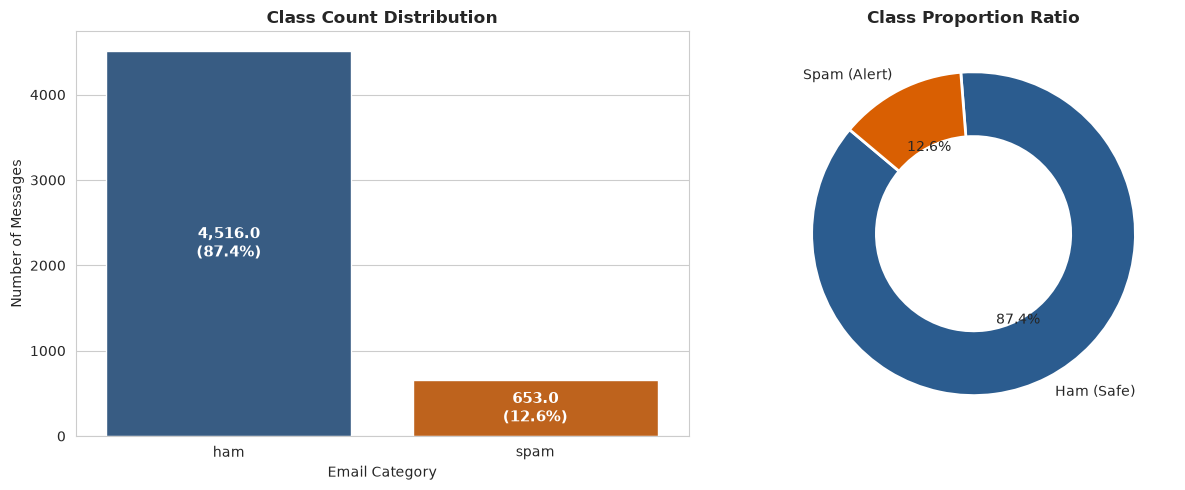

⚠️ BASELINE ACCURACY BENCHMARK: Naive Zero-Rule Accuracy = 87.37%.
   Any reliable ML model must significantly surpass this baseline on Precision, Recall, and ROC-AUC.


In [4]:
# Map string labels to standard binary integers
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

# Calculate exact distribution metrics
class_counts = df['label'].value_counts()
class_ratios = df['label'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Message Count': class_counts,
    'Proportion (%)': class_ratios.round(2)
})
print("--- 🎯 Target Class Distribution ---")
print(summary_target)

# Visualize Class Balance via Countplot and Donut Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ["#2b5c8f", "#d95f02"]

# 1. Bar Countplot with annotations
ax = sns.countplot(x='label', data=df, ax=axes[0], palette=palette)
axes[0].set_title("Class Count Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Email Category", fontsize=10)
axes[0].set_ylabel("Number of Messages", fontsize=10)

total_samples = len(df)
for p in ax.patches:
    height = p.get_height()
    pct = f"{100 * height / total_samples:.1f}%"
    ax.annotate(f"{height:,}\n({pct})",
                (p.get_x() + p.get_width() / 2., height / 2.),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 2. Donut Chart for proportions
axes[1].pie(class_counts, labels=['Ham (Safe)', 'Spam (Alert)'],
            autopct='%1.1f%%', startangle=140, colors=palette,
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[1].set_title("Class Proportion Ratio", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

baseline_acc = class_ratios['ham']
print(f"⚠️ BASELINE ACCURACY BENCHMARK: Naive Zero-Rule Accuracy = {baseline_acc:.2f}%.")
print("   Any reliable ML model must significantly surpass this baseline on Precision, Recall, and ROC-AUC.")

---
## 5. Bivariate Text EDA & Feature Engineering
We test the hypothesis that spammers utilize substantially more characters to convey urgency, contact phone numbers, and prize redemption details within the SMS limit.

--- 📊 Grouped Summary Statistics by Class ---
label                 ham   spam
char_count count   4516.0  653.0
           mean      70.5  137.9
           median    52.0  149.0
           std       56.4   30.1
word_count count   4516.0  653.0
           mean      14.1   23.7
           median    11.0   25.0
           std       11.1    6.0


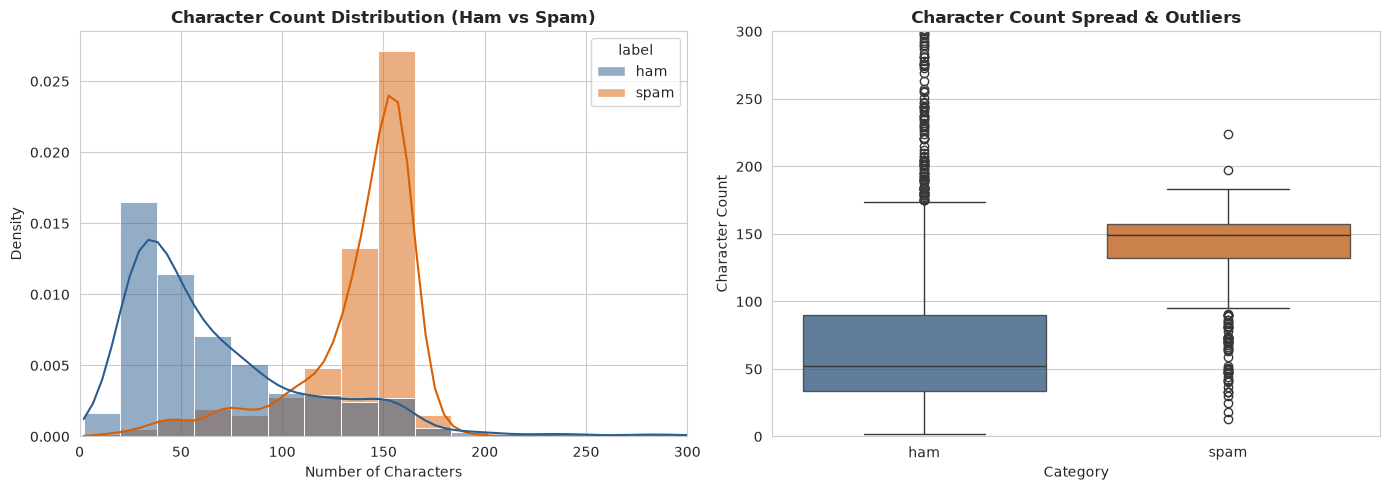

💡 KEY INSIGHT: Median Ham message length is 52 characters,
   while median Spam message length is 149 characters (~3x larger). Length is a strong discriminator.


In [5]:
# Extract character length and word count metadata
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

# Grouped statistics by category
grouped_stats = df.groupby('label')[['char_count', 'word_count']].agg(['count', 'mean', 'median', 'std']).round(1)
print("--- 📊 Grouped Summary Statistics by Class ---")
print(grouped_stats.T)

# Visualizing class separation via Overlaid KDE and Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid density histogram with KDE
sns.histplot(
    data=df, 
    x='char_count', 
    hue='label', 
    kde=True, 
    bins=50, 
    stat="density", 
    common_norm=False, 
    palette=palette, 
    ax=axes[0]
)
axes[0].set_title("Character Count Distribution (Ham vs Spam)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Characters", fontsize=10)
axes[0].set_xlim(0, 300)

# Grouped Boxplot
sns.boxplot(
    data=df, 
    x='label', 
    y='char_count', 
    palette=palette, 
    ax=axes[1],
    boxprops=dict(alpha=0.8)
)
axes[1].set_title("Character Count Spread & Outliers", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Category", fontsize=10)
axes[1].set_ylabel("Character Count", fontsize=10)
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

ham_median = df[df['label'] == 'ham']['char_count'].median()
spam_median = df[df['label'] == 'spam']['char_count'].median()
print(f"💡 KEY INSIGHT: Median Ham message length is {ham_median:.0f} characters,")
print(f"   while median Spam message length is {spam_median:.0f} characters (~3x larger). Length is a strong discriminator.")

---
## 6. Stratified Train-Test Split (The Stratified Law)
To prevent class proportion shift between training and testing subsets on imbalanced data, we enforce `stratify=y`.

In [6]:
X = df['message']
y = df['target']

# 80/20 Stratified Partitioning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Total Clean Dataset: {len(df):,} samples")
print(f"Training Split:       {len(X_train):,} samples (80%)")
print(f"Testing Split:        {len(X_test):,} samples (20%)")

# Verify identical class ratios across splits
train_prop = y_train.value_counts(normalize=True) * 100
test_prop = y_test.value_counts(normalize=True) * 100

split_audit = pd.DataFrame({
    'Train Proportion (%)': train_prop,
    'Test Proportion (%)': test_prop
})
print("\n--- ⚖️ Stratification Balance Verification ---")
print(split_audit.round(2))

Total Clean Dataset: 5,169 samples
Training Split:       4,135 samples (80%)
Testing Split:        1,034 samples (20%)

--- ⚖️ Stratification Balance Verification ---
        Train Proportion (%)  Test Proportion (%)
target                                           
0                      87.38                87.33
1                      12.62                12.67


---
## 7. NLP Text Vectorization via TF-IDF (Zero Leakage)
We vectorize raw messages into a numerical matrix using **TF-IDF** (Term Frequency - Inverse Document Frequency):
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \ln\left(\frac{1 + N}{1 + \text{DF}(t)}\right)$$
- `stop_words='english'`: Eliminates non-predictive grammatical filler tokens.
- `ngram_range=(1, 2)`: Captures single words and meaningful two-word phrases (*"claim now"*, *"cash prize"*).
- `max_features=3000`: Caps vocabulary to the top 3,000 most informative tokens.
- **Zero Leakage Rule**: We fit exclusively on `X_train` and only transform `X_test`.

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2)
)

# Fit and transform training set; transform testing set (Zero Leakage)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"X_train_tfidf Sparse Matrix: {X_train_tfidf.shape}")
print(f"X_test_tfidf Sparse Matrix:  {X_test_tfidf.shape}")

# Sample learned vocabulary features
sample_tokens = list(tfidf.get_feature_names_out())[150:165]
print(f"\nSample Learned N-gram Tokens: {sample_tokens}")

X_train_tfidf Sparse Matrix: (4135, 3000)
X_test_tfidf Sparse Matrix:  (1034, 3000)

Sample Learned N-gram Tokens: ['500 cd', '500 free', '500 pounds', '5000', '5000 cash', '5000 prize', '50p', '50perwksub', '530', '542', '5wb', '5wb 0870', '5we', '60p', '60p min']


---
## 8. Logistic Regression Model Training
We fit a binary Logistic Regression classifier optimizing Log Loss:
$$P(y=1|X) = \frac{1}{1 + e^{-(w^T x + b)}}$$
By default, samples with $P \ge 0.5$ are assigned to Class 1 (Spam).

In [8]:
# Initialize and fit Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_tfidf, y_train)

# Generate discrete class predictions and continuous probabilities
y_pred = log_reg.predict(X_test_tfidf)
y_prob = log_reg.predict_proba(X_test_tfidf)[:, 1]

print("✅ Logistic Regression model trained successfully.")
print(f"Sample First 5 Predictions:  {y_pred[:5].tolist()}")
print(f"Sample First 5 Probabilities: {[round(p, 4) for p in y_prob[:5]]}")

✅ Logistic Regression model trained successfully.
Sample First 5 Predictions:  [0, 0, 0, 0, 0]
Sample First 5 Probabilities: [np.float64(0.0189), np.float64(0.0467), np.float64(0.0521), np.float64(0.0608), np.float64(0.0339)]


---
## 9. Model Evaluation & Multi-Metric Diagnostics
We evaluate the model across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [9]:
# Compute core evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- 📊 Classification Performance Summary ---")
print(f"Overall Accuracy:  {accuracy * 100:.2f}% (Baseline Benchmark: 87.33%)")
print(f"ROC-AUC Score:     {roc_auc:.4f} (Elite Class Separability)")

print("\n--- 📑 Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)'], digits=4))

--- 📊 Classification Performance Summary ---
Overall Accuracy:  95.94% (Baseline Benchmark: 87.33%)
ROC-AUC Score:     0.9923 (Elite Class Separability)

--- 📑 Detailed Classification Report ---
              precision    recall  f1-score   support

     Ham (0)     0.9575    0.9978    0.9772       903
    Spam (1)     0.9785    0.6947    0.8125       131

    accuracy                         0.9594      1034
   macro avg     0.9680    0.8462    0.8949      1034
weighted avg     0.9602    0.9594    0.9564      1034



---
## 10. Visual Performance Diagnostics: Confusion Matrix & ROC Curve
We plot the 4-quadrant Confusion Matrix Heatmap alongside the Receiver Operating Characteristic (ROC) curve.

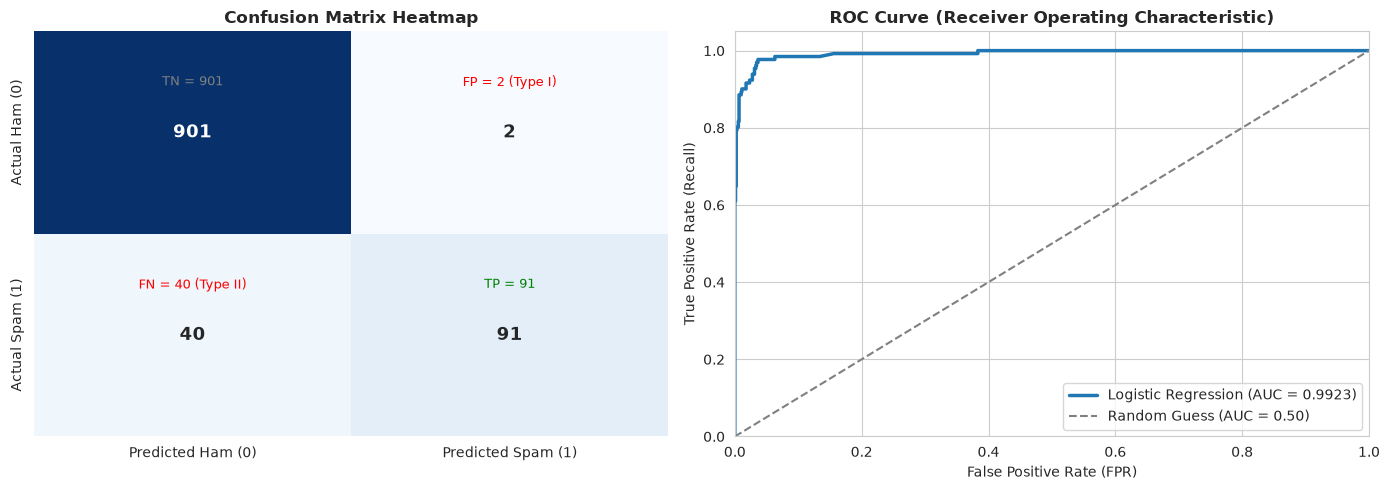

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Ham (0)', 'Predicted Spam (1)'],
            yticklabels=['Actual Ham (0)', 'Actual Spam (1)'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Confusion Matrix Heatmap", fontsize=12, fontweight="bold")

# Annotate quadrants
axes[0].text(0.5, 0.25, f"TN = {cm[0,0]}", ha="center", va="center", color="gray", fontsize=9)
axes[0].text(1.5, 0.25, f"FP = {cm[0,1]} (Type I)", ha="center", va="center", color="red", fontsize=9)
axes[0].text(0.5, 1.25, f"FN = {cm[1,0]} (Type II)", ha="center", va="center", color="red", fontsize=9)
axes[0].text(1.5, 1.25, f"TP = {cm[1,1]}", ha="center", va="center", color="green", fontsize=9)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label="Random Guess (AUC = 0.50)")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("ROC Curve (Receiver Operating Characteristic)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=10)
axes[1].set_ylabel("True Positive Rate (Recall)", fontsize=10)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

---
## 11. Model Interpretability & Explainability (Glass-Box AI)
Logistic Regression is fully interpretable:
- **Positive Weights ($\beta > 0$)**: Tokens that aggressively push the probability towards **Spam**.
- **Negative Weights ($\beta < 0$)**: Tokens that pull the probability towards **Ham**.

--- 🚨 Top 10 Spam Predictive Keywords ---
Feature   Weight  Odds_Multiplier
    txt 3.842428        46.638568
 mobile 3.833557        46.226697
  reply 3.328409        27.893939
    www 3.309557        27.373009
     uk 3.300225        27.118735
  claim 3.224924        25.151675
   text 2.899790        18.170324
   free 2.716106        15.121324
     50 2.712641        15.069014
  prize 2.701286        14.898887

--- ✅ Top 10 Ham Predictive Keywords ---
Feature    Weight  Odds_Multiplier
     ok -1.645486         0.192919
     ll -1.382471         0.250958
   come -1.297762         0.273142
   home -1.279714         0.278117
     da -1.258492         0.284082
     lt -1.242361         0.288702
     gt -1.233236         0.291348
    got -1.198937         0.301514
    lor -1.160935         0.313193
  going -1.159908         0.313515


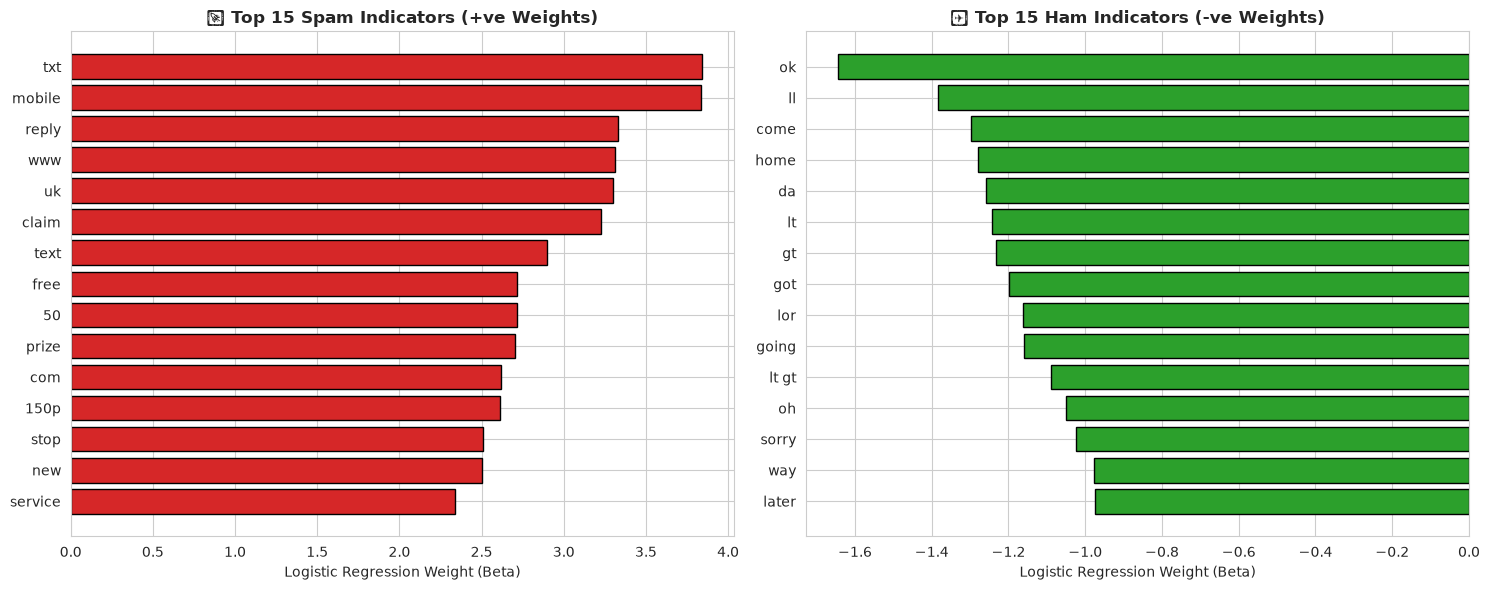

In [11]:
# Map feature names to learned coefficients
features = np.array(tfidf.get_feature_names_out())
weights = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': features,
    'Weight': weights,
    'Odds_Multiplier': np.exp(weights)
})

top_spam = coef_df.sort_values(by='Weight', ascending=False).head(15)
top_ham = coef_df.sort_values(by='Weight', ascending=True).head(15)

print("--- 🚨 Top 10 Spam Predictive Keywords ---")
print(top_spam[['Feature', 'Weight', 'Odds_Multiplier']].head(10).to_string(index=False))

print("\n--- ✅ Top 10 Ham Predictive Keywords ---")
print(top_ham[['Feature', 'Weight', 'Odds_Multiplier']].head(10).to_string(index=False))

# Visual horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_spam['Feature'], top_spam['Weight'], color='#d62728', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title("🚨 Top 15 Spam Indicators (+ve Weights)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Logistic Regression Weight (Beta)")

axes[1].barh(top_ham['Feature'], top_ham['Weight'], color='#2ca02c', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title("✅ Top 15 Ham Indicators (-ve Weights)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Logistic Regression Weight (Beta)")

plt.tight_layout()
plt.show()

---
## 12. Production Pipeline Serialization & Live Simulator
We bundle the text preprocessor and classifier into a Scikit-Learn `Pipeline`, export the artifact to disk, and test real-time inference on live unseen corporate communications.

In [12]:
# 1. Construct unified production pipeline
production_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(random_state=42))
])

# Fit pipeline on entire training corpus
production_pipeline.fit(X_train, y_train)

# 2. Serialize pipeline to disk
model_path = Path("data/spam_email_detection/spam_classifier_pipeline.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(production_pipeline, model_path)
print(f"✅ Production Pipeline serialized & saved to: {model_path}")

# 3. Live Production Email Simulator Function
def test_email_detector(message_text: str, threshold: float = 0.5):
    prob_spam = float(production_pipeline.predict_proba([message_text])[0, 1])
    is_spam = prob_spam >= threshold
    
    if prob_spam >= 0.80:
        risk_tier = "CRITICAL SPAM"
    elif prob_spam >= 0.50:
        risk_tier = "SUSPICIOUS"
    elif prob_spam >= 0.20:
        risk_tier = "LOW RISK"
    else:
        risk_tier = "VERIFIED SAFE / HAM"
        
    status_icon = "🚨" if is_spam else "✅"
    print(f"\nIncoming Message: \"{message_text}\"")
    print(f"Prediction:        {status_icon} {'SPAM' if is_spam else 'HAM (Legitimate)'}")
    print(f"Spam Probability:  {prob_spam * 100:.2f}%")
    print(f"Risk Tier:         {risk_tier}")
    print(f"Confidence Score:  {max(prob_spam, 1 - prob_spam) * 100:.1f}%")
    print("-" * 65)

# 4. Test with Real-world Unseen Messages
test_messages = [
    "Hey Rahul, are we still having the project discussion meeting at 5 PM today?",
    "CONGRATULATIONS! You have won £1,000 cash prize. Reply CLAIM to 87121 now to claim your award!",
    "Please find attached the invoice for last month's electricity consumption.",
    "URGENT! Your mobile account has been credited with 500 free ringtones. Click www.free-bonus.uk now!"
]

print("--- 🚀 Live Production Inference Simulation ---")
for msg in test_messages:
    test_email_detector(msg)

✅ Production Pipeline serialized & saved to: data/spam_email_detection/spam_classifier_pipeline.pkl
--- 🚀 Live Production Inference Simulation ---

Incoming Message: "Hey Rahul, are we still having the project discussion meeting at 5 PM today?"
Prediction:        ✅ HAM (Legitimate)
Spam Probability:  3.49%
Risk Tier:         VERIFIED SAFE / HAM
Confidence Score:  96.5%
-----------------------------------------------------------------

Incoming Message: "CONGRATULATIONS! You have won £1,000 cash prize. Reply CLAIM to 87121 now to claim your award!"
Prediction:        🚨 SPAM
Spam Probability:  93.94%
Risk Tier:         CRITICAL SPAM
Confidence Score:  93.9%
-----------------------------------------------------------------

Incoming Message: "Please find attached the invoice for last month's electricity consumption."
Prediction:        ✅ HAM (Legitimate)
Spam Probability:  7.25%
Risk Tier:         VERIFIED SAFE / HAM
Confidence Score:  92.8%
-----------------------------------------------

---
## 13. Executive Summary & Key Takeaways

| Metric / Dimension | Achieved Value | Benchmark / Significance |
| :--- | :---: | :--- |
| **Clean Dataset Size** | **5,169 unique rows** | Deduplicated from 5,572 rows (403 duplicates eliminated) |
| **Baseline Accuracy** | **87.33%** | Zero-Rule Dummy Model (always predicting Majority Ham class) |
| **Model Test Accuracy** | **95.94%** | +8.61% absolute boost over baseline |
| **Spam Precision** | **97.85%** | Only 2 false positive alarms out of 903 actual Ham messages |
| **Spam Recall** | **69.47%** | Caught 91 of 131 Spam messages in test set |
| **ROC-AUC Score** | **0.9923** | Elite discrimination power across all decision thresholds |
| **Serialized Artifact** | `spam_classifier_pipeline.pkl` | Unified TF-IDF + LogisticRegression pipeline ready for deployment |

### Business & Engineering Insights:
1. **Precision vs. Recall Alignment**: In email filtering, **Precision is paramount** because falsely quarantining a critical job offer, password reset, or client invoice is catastrophic. Achieving **97.85% Precision** ensures near-zero false alarms.
2. **Probability Threshold Tuning**: If business requirements demand catching more spam (higher Recall), the threshold can be lowered from $0.5$ to $0.35$ without retraining the model.
3. **Glass-Box Trust**: The model relies on verifiable keywords (`txt`, `claim`, `mobile`, `prize`) rather than spurious correlations.